In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd

hpd.util.get_color_logger("INFO")

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = (90_600, 91_047, 441_032, 441_272) # Rijksdriehoek (xmin, xmax, ymin, ymax)
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 2
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|███████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.32it/s]


In [4]:
gw = oc.obs["GMW000000036741001"]
print(gw)

GroundwaterObs GMW000000036741001
-----metadata------
name : GMW000000036741001 
x : 90998.68787131566 
y : 441239.3184593285 
location : MEIJPL-12 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -15.68 
screen_bottom : -16.68 
ground_level : -4.56 
tube_top : -2.68 
metadata_available : True 

-----time series------
                     value  flag        comment origin
peil_datum_tijd                                       
2007-09-13 23:00:00  -4.03   NaN        Gemeten   hand
2007-09-18 23:00:00  -4.35   NaN        Gemeten   hand
2019-11-13 08:00:00    NaN   NaN  niet te meten   hand
2019-11-28 13:30:00    NaN   NaN  niet te meten   hand
2020-01-10 13:29:00    NaN   NaN  niet te meten   hand
...                    ...   ...            ...    ...
2025-08-04 12:03:33  -4.18   2.0        Gemeten   hand
2025-09-04 09:18:08  -4.19   2.0        Gemeten   hand
2025-10-01 12:21:49  -4.21   2.0        Gemeten   hand
2025-11-06 15:02:13  -4.07   2.0        Gemeten   han

In [5]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)


2007-09-13 23:00:00 2025-12-10 08:05:58
(67,)


In [6]:
ts = ts.loc["2024-11-01":"2025-10-31"]

In [7]:
percentile = 0.30
threshold = ts.quantile(percentile)

print(f"Fixed threshold (30th percentile): {threshold:.2f} m NAP")

Fixed threshold (30th percentile): -4.21 m NAP


In [8]:
is_drought = ts < threshold

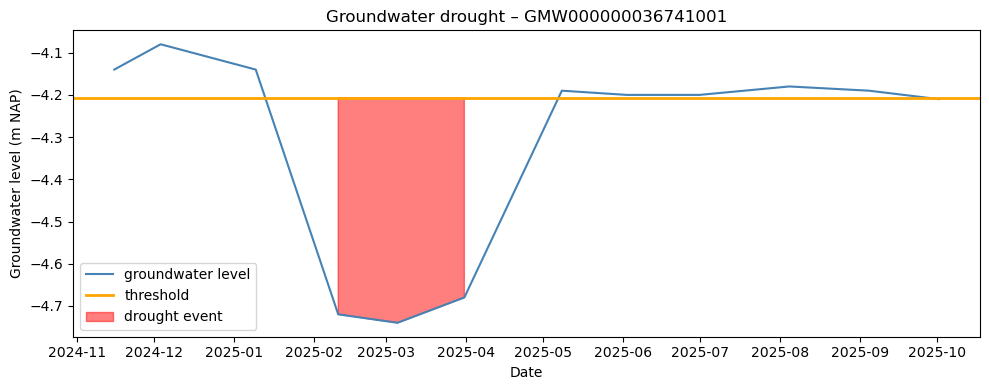

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

# Groundwater level
ax.plot(ts.index, ts, color="steelblue", label="groundwater level")

# Fixed threshold
ax.axhline(threshold, color="orange", linewidth=2, label="threshold")

# Drought deficit
ax.fill_between(
    ts.index,
    ts,
    threshold,
    where=is_drought,
    color="red",
    alpha=0.5,
    label="drought event",
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – {gw.name}")
ax.legend()

# Important for groundwater plots
# ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [10]:
duration_days = is_drought.sum()
max_deficit = (threshold - ts[is_drought]).max()

print(f"Drought duration: {duration_days} days")
print(f"Maximum deficit: {max_deficit:.2f} m")


Drought duration: 4 days
Maximum deficit: 0.53 m
